In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
df = pd.read_parquet("../data/processed/spy_processed.parquet")
# to avoid taking same OI into dex calculation multiple times, drop duplicate
key_cols = ['timestamp', 'strike', 'right']
dupes = df[df.duplicated(key_cols, keep=False)]
print(f"Duplicate rows: {len(dupes)}")

Duplicate rows: 0


In [3]:
# Delta is already signed: calls positive, puts negative
# Dealer is short what customer is long → flip sign
df['dex'] = -df['delta'] * df['open_interest'] * df['underlying_price'] * 100
dex_by_time = df.groupby('timestamp')['dex'].sum().reset_index()
dex_by_time.columns = ['timestamp', 'net_dex']

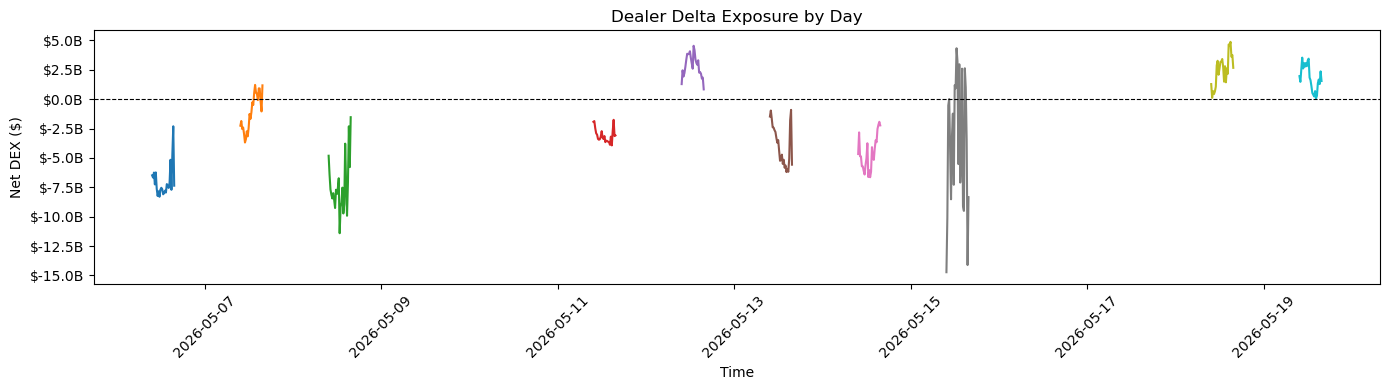

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in dex_by_time.groupby(dex_by_time['timestamp'].dt.date):
    ax.plot(group['timestamp'], group['net_dex'], label=str(date))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Net DEX ($)')
ax.set_title('Dealer Delta Exposure by Day')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# Gamma is always positive (same for calls and puts in BS)
# Calls: +gamma contribution (dealer short call → hedging creates pinning pressure)
# Puts: -gamma contribution (dealer short put → hedging amplifies downside moves)
# uses dollars per 1% move convention for gex calculation
df['gex'] = df['gamma'].where(df['right'] == 'CALL', -df['gamma']) * df['open_interest'] * df['underlying_price']**2 * 100 * 0.01

gex_by_time = df.groupby('timestamp')['gex'].sum().reset_index()
gex_by_time.columns = ['timestamp', 'net_gex']

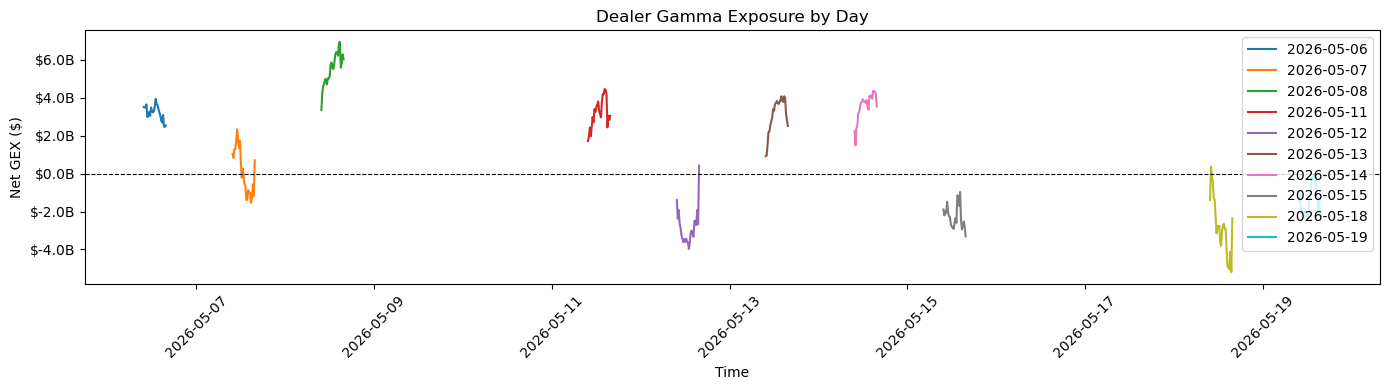

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in gex_by_time.groupby(gex_by_time['timestamp'].dt.date):
    ax.plot(group['timestamp'], group['net_gex'], label=str(date))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Net GEX ($)')
ax.set_title('Dealer Gamma Exposure by Day')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()